# Домашнее задание: Занятие 30

**Тема: Реализация CNN в PyTorch**

В этом задании вы самостоятельно построите и обучите CNN на CIFAR-10. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория

Ответьте на вопросы в markdown-ячейках ниже. Пишите своими словами, не копируйте.

### Вопрос 1

*(Слайд 5-6)*

Чем отличается картинка CIFAR-10 от картинки MNIST? Укажите:
- размер
- количество каналов
- сколько чисел описывают одну картинку в каждом датасете

**Ваш ответ:**
У MNIST размер меньше, меньше чисел, один канал и черно-белая картинка. У Cifar всего больше, при этом картинка цветная


### Вопрос 2

*(Слайд 7)*

Допустим, у нас есть слой `Conv2d(3, 16, kernel_size=5, padding=0)`. Посчитайте:
- Какой размер одного фильтра?
- Сколько весов в одном фильтре?
- Сколько всего параметров в этом слое (с bias)?
- Если на вход подается картинка 32x32x3, какой будет размер выхода?

**Ваш ответ:**

Какой размер одного фильтра? - 5х5х3

Сколько весов в одном фильтре? - 75

Сколько всего параметров в этом слое (с bias)? - 1260

Если на вход подается картинка 32x32x3, какой будет размер выхода? - 28x28x16


### Вопрос 3

*(Слайд 12)*

Зачем нужен BatchNorm? Куда его ставить в последовательности Conv -> ? -> ReLU? Что меняется если мы его уберем?

**Ваш ответ:**
Нужен для ускорения обучения и стабильности. Он нормализует выходы слоев, чтобы они не становились слишком большими или маленькими. Если его убрать, модель будет учиться гораздо медленнее и станет очень чувствительной к начальной настройке весов


### Вопрос 4

*(Слайд 13-14)*

Опишите 4 шага training loop своими словами. Для каждого шага напишите одну строчку кода из PyTorch, которая ему соответствует.

**Ваш ответ:**

1. Обнуление градиентов: Очищаем память от старых расчетов. optimizer.zero_grad()

2. Прямой проход: Прогоняем картинку через нейросеть. outputs = model(images)

3. Расчет ошибки: Сравниваем ответ сети с правильным. loss = criterion(outputs, labels)

4. Обратный проход и шаг: Считаем, как нужно изменить веса, и обновляем их. loss.backward() и optimizer.step()

### Вопрос 5

*(Слайд 16)*

Посмотрите на графики ниже. Определите для каждого: хорошее обучение, переобучение, или недообучение? Объясните почему.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(1, 21)

# График A
np.random.seed(1)
axes[0].plot(epochs, 1.5*np.exp(-0.15*epochs)+0.3+np.random.randn(20)*0.02, 'b-', lw=2, label='Train')
axes[0].plot(epochs, 1.5*np.exp(-0.08*epochs)+0.5+0.04*epochs+np.random.randn(20)*0.03, 'r--', lw=2, label='Val')
axes[0].set_title('График A'); axes[0].legend(); axes[0].grid(alpha=0.3)

# График B
np.random.seed(2)
axes[1].plot(epochs, 2.0*np.exp(-0.2*epochs)+0.15+np.random.randn(20)*0.02, 'b-', lw=2, label='Train')
axes[1].plot(epochs, 2.0*np.exp(-0.18*epochs)+0.2+np.random.randn(20)*0.03, 'r--', lw=2, label='Val')
axes[1].set_title('График B'); axes[1].legend(); axes[1].grid(alpha=0.3)

# График C
np.random.seed(3)
axes[2].plot(epochs, 1.8*np.exp(-0.03*epochs)+1.0+np.random.randn(20)*0.03, 'b-', lw=2, label='Train')
axes[2].plot(epochs, 1.8*np.exp(-0.025*epochs)+1.1+np.random.randn(20)*0.04, 'r--', lw=2, label='Val')
axes[2].set_title('График C'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

**Ваш ответ:**

- График A: Переобучение. Ошибка на обучении падает, а на валидации начала расти. Сеть начала зубрить конкретные примеры вместо понимания правил.
- График B: Хорошее обучение. Обе линии плавно и синхронно идут вниз. Модель успешно обобщает знания.
- График C: Недообучение. Ошибка падает крайне медленно и остается очень высокой. Сети не хватает сложности или времени, чтобы выучить данные.


---

## Часть 2: Код

### Подготовка

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


### Задание 1: Загрузите CIFAR-10 с нормализацией

*(Слайд 5, 17)*

Создайте два набора трансформаций:
- `transform_train` -- с аугментацией (RandomHorizontalFlip, RandomCrop с padding=4) и нормализацией
- `transform_test` -- только ToTensor и нормализация

Средние значения каналов CIFAR-10: (0.4914, 0.4822, 0.4465), стандартные отклонения: (0.2470, 0.2435, 0.2616).

Создайте DataLoader с batch_size=64.

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train: {len(train_dataset)} картинок, {len(train_loader)} батчей')
print(f'Test: {len(test_dataset)} картинок, {len(test_loader)} батчей')

100%|██████████| 170M/170M [00:03<00:00, 48.1MB/s]


Train: 50000 картинок, 782 батчей
Test: 10000 картинок, 157 батчей


### Задание 2: Постройте CNN

*(Слайды 9-12)*

Напишите свою CNN с такой архитектурой:

| Блок | Слои | Выход |
|------|------|-------|
| 1 | Conv2d(3, 32, 3, padding=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2) | 16x16x32 |
| 2 | Conv2d(32, 64, 3, padding=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2) | 8x8x64 |
| 3 | Conv2d(64, 128, 3, padding=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2) | 4x4x128 |
| Classifier | Flatten -> Linear(2048, 256) -> ReLU -> Dropout(0.5) -> Linear(256, 10) | 10 |

Обратите внимание: добавьте `nn.Dropout(0.5)` перед последним Linear -- это еще один способ борьбы с переобучением. Dropout случайно выключает 50% нейронов при обучении.

In [3]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Блок 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Блок 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Проверка
model = MyCNN().to(device)
test_input = torch.randn(1, 3, 32, 32).to(device)
print(f'Выход: {model(test_input).shape}')
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

Выход: torch.Size([1, 10])
Параметров: 620,810


### Задание 3: Проследите размеры

*(Слайд 10, 18)*

Пропустите тензор `torch.randn(1, 3, 32, 32)` через каждый слой вашей модели по одному и выведите размер после каждого слоя. Убедитесь, что размеры совпадают с таблицей на слайде 18.

In [4]:
x = torch.randn(1, 3, 32, 32).to(device)
print(f'Вход: {x.shape}')

print("\n--- Проход через features ---")
for layer in model.features:
    x = layer(x)
    print(f"После {layer.__class__.__name__}: {x.shape}")

print("\n--- Проход через classifier ---")
for layer in model.classifier:
    x = layer(x)
    print(f"После {layer.__class__.__name__}: {x.shape}")

Вход: torch.Size([1, 3, 32, 32])

--- Проход через features ---
После Conv2d: torch.Size([1, 32, 32, 32])
После BatchNorm2d: torch.Size([1, 32, 32, 32])
После ReLU: torch.Size([1, 32, 32, 32])
После MaxPool2d: torch.Size([1, 32, 16, 16])
После Conv2d: torch.Size([1, 64, 16, 16])
После BatchNorm2d: torch.Size([1, 64, 16, 16])
После ReLU: torch.Size([1, 64, 16, 16])
После MaxPool2d: torch.Size([1, 64, 8, 8])
После Conv2d: torch.Size([1, 128, 8, 8])
После BatchNorm2d: torch.Size([1, 128, 8, 8])
После ReLU: torch.Size([1, 128, 8, 8])
После MaxPool2d: torch.Size([1, 128, 4, 4])

--- Проход через classifier ---
После Flatten: torch.Size([1, 2048])
После Linear: torch.Size([1, 256])
После ReLU: torch.Size([1, 256])
После Dropout: torch.Size([1, 256])
После Linear: torch.Size([1, 10])


### Задание 4: Обучите модель

*(Слайды 13-15)*

Напишите training loop на 10 эпох. Используйте:
- CrossEntropyLoss
- Adam с lr=0.001

Сохраняйте train_loss и test_accuracy на каждой эпохе.

In [5]:
model = MyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Функция для подсчета accuracy
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return correct / total

In [6]:
num_epochs = 10
train_losses = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 4 шага обучения
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    acc = evaluate(model, test_loader)

    train_losses.append(avg_loss)
    test_accs.append(acc)

    print(f'Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Test Acc: {acc:.4f}')

Epoch  1 | Loss: 1.5678 | Test Acc: 0.5152
Epoch  2 | Loss: 1.2553 | Test Acc: 0.6377
Epoch  3 | Loss: 1.1241 | Test Acc: 0.6774
Epoch  4 | Loss: 1.0534 | Test Acc: 0.6848
Epoch  5 | Loss: 0.9803 | Test Acc: 0.7052
Epoch  6 | Loss: 0.9451 | Test Acc: 0.7245
Epoch  7 | Loss: 0.9008 | Test Acc: 0.7407
Epoch  8 | Loss: 0.8658 | Test Acc: 0.7471
Epoch  9 | Loss: 0.8317 | Test Acc: 0.7649
Epoch 10 | Loss: 0.8084 | Test Acc: 0.7625


### Задание 5: Постройте графики

*(Слайд 16)*

Постройте два графика рядом:
- Train Loss по эпохам
- Test Accuracy по эпохам

Какая accuracy получилась? Есть ли признаки переобучения?

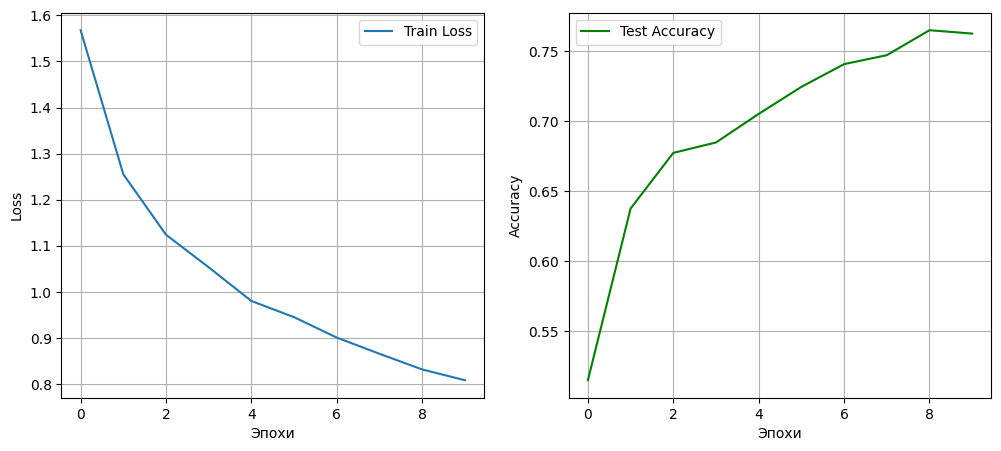

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy', color='green')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

**Ваш вывод:**



### Задание 6: Accuracy по классам

*(Слайд 8)*

Посчитайте accuracy для каждого из 10 классов отдельно. Какой класс модель предсказывает лучше всего? Какой хуже всего? Почему?

In [8]:
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
classes_ru = ('Самолёт', 'Машина', 'Птица', 'Кот', 'Олень',
              'Собака', 'Лягушка', 'Лошадь', 'Корабль', 'Грузовик')

correct_per_class = [0] * 10
total_per_class = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_per_class[label] += 1
            total_per_class[label] += 1

for i in range(10):
    accuracy = 100 * correct_per_class[i] / total_per_class[i]
    print(f'{classes_ru[i]:<10}: {accuracy:.1f}%')

Самолёт   : 76.2%
Машина    : 92.1%
Птица     : 65.5%
Кот       : 59.9%
Олень     : 83.1%
Собака    : 52.9%
Лягушка   : 73.2%
Лошадь    : 83.5%
Корабль   : 94.1%
Грузовик  : 82.0%


**Ваш вывод:**



---

## Часть 3: Бонус

### Бонус 1: Confusion Matrix

Постройте confusion matrix для вашей модели на тестовых данных. Какие классы чаще всего путаются между собой?

Подсказка: используйте `sklearn.metrics.confusion_matrix` и `plt.imshow`.

In [ ]:
# Ваш код здесь



### Бонус 2: Эксперимент с архитектурой

Попробуйте изменить архитектуру и посмотрите, как это влияет на результат. Например:
- Уберите BatchNorm и обучите заново. Насколько хуже стало?
- Добавьте 4-й сверточный блок (128 -> 256). Помогло?
- Замените MaxPool на AveragePool. Есть разница?

Выберите один эксперимент, проведите и опишите результат.

In [ ]:
# Ваш код здесь



**Ваш вывод:**

